In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Assumes this is run from the experiments directory with the scm package in the parent
sys.path.insert(0, '..')

from scm import SBMGenerator, CIC3Simulator
from scm import MultiRandomSeeding, MultiHighDegreeSeeding
from scm.analysis import time_discounted_attainment, no_decay, exponential_decay

# --- Global Parameters ---
N = 2000
CORE_SIZE = 200
C = 10
BETA = 0.04
BETA_DELTA = 0.03
T_MAX = 1000
NUM_TRIALS = 15
NUM_SEEDS_PER_CONTAGION = 1
# V = no_decay()
V = exponential_decay(0.5)

# --- Periphery Intra-Community Probability ---
# This is the probability of an edge within a single periphery community.
# Easy to change — just update this one value.
P_PERIPH_INTRA = 0.3

# --- Sweep Parameters ---
GRID_RESOLUTION = 10

# Continuous sweep ranges for axes
SWEEPS = {
    'P_CC': np.linspace(0.3, 0.3, 1),    # Core density
    'P_PI': np.linspace(0.001, 0.3, GRID_RESOLUTION),  # Periphery inter-community density
    'P_CP': np.linspace(0.001, 0.3, GRID_RESOLUTION)   # Core-Periphery bridge
}

# Discrete values for the fixed third variable
DISCRETE = {
    'P_CC': [0.2, 0.5, 0.8],
    'P_PI': [0.001, 0.01, 0.05],
    'P_CP': [0.001, 0.01, 0.05]
}

# Unordered combinations: (fixed_var, y_axis_var, x_axis_var)
EXPERIMENTS = [
    # ('P_CP', 'P_CC', 'P_PI'),
    # ('P_PI', 'P_CC', 'P_CP'),
    ('P_CC', 'P_CP', 'P_PI')
]

LABELS = {
    'P_CC': "Core Density ($P_{CC}$)",
    'P_PI': "Periphery Inter-Density ($P_{PI}$)",
    'P_CP': "Core-Periphery Bridge ($P_{CP}$)"
}

In [2]:
def make_quotas_and_seeds(N_topo, C=C, seed_frac_divisor=5):
    base = N_topo // C
    rem = N_topo - base * C
    quotas = [base + 1] * rem + [base] * (C - rem)
    seeds = [NUM_SEEDS_PER_CONTAGION] * C # [max(1, q // seed_frac_divisor) for q in quotas]
    return quotas, seeds

def make_core_periphery_kwargs(p_cc, p_pi, p_cp, N=N, core_size=CORE_SIZE,
                                p_periph_intra=P_PERIPH_INTRA):
    periph_K = 9
    periph_size = (N - core_size) // periph_K
    sizes = [core_size] + [periph_size] * periph_K
    K = len(sizes)
    
    P = np.zeros((K, K))
    P[0, 0] = p_cc
    
    for i in range(1, K):
        P[0, i] = p_cp
        P[i, 0] = p_cp
        P[i, i] = p_periph_intra       # Intra-community (diagonal)
        for j in range(i + 1, K):
            P[i, j] = p_pi              # Inter-community (off-diagonal)
            P[j, i] = p_pi
            
    T = np.zeros(K)
    T[0] = p_cc * 0.25 
    T[1:] = p_periph_intra * 0.25       # Triangles scale with intra-community density
    
    return {
        "community_sizes": sizes,
        "block_matrix": P.tolist(),
        "triangle_block_probs": T.tolist()
    }

def evaluate_strategy(strat_cls, topo_links, topo_triangles, quotas, seeds):
    seeder = strat_cls(
        N=N, num_seeds_per_contagion=seeds,
        links=topo_links, triangles=topo_triangles,
    )
    initial_infected = seeder.seed()
    
    sim = CIC3Simulator(
        links=topo_links, triangles=topo_triangles,
        initial_infected_per_contagion=initial_infected,
        betas=[BETA] * C, beta_deltas=[BETA_DELTA] * C, quotas=quotas,
    )
    sim.run(T_MAX)
    
    _, A_g_td = time_discounted_attainment(sim.infected_by, sim.infection_times, quotas, V)
    return A_g_td

In [ ]:
os.makedirs("results", exist_ok=True)
results_file = "../results/cic3_combinatorial_sweep.pkl"

if os.path.exists(results_file):
    print("Loading existing sweep results...")
    with open(results_file, "rb") as f:
        all_results = pickle.load(f)
else:
    all_results = {}
    print("Running combinatorial parameter sweep. This will take a moment...")
    
    for fixed_var, y_var, x_var in EXPERIMENTS:
        print(f"\n=== Sweeping {y_var} (Y) and {x_var} (X) | Fixing {fixed_var} ===")
        
        # Result tensor: [fixed_idx, y_idx, x_idx]
        tensor = np.zeros((3, GRID_RESOLUTION, GRID_RESOLUTION))
        
        fixed_vals = DISCRETE[fixed_var]
        y_vals = SWEEPS[y_var]
        x_vals = SWEEPS[x_var]
        
        for i, fixed_val in enumerate(fixed_vals):
            print(f"  [{i+1}/3] Fixed {fixed_var} = {fixed_val}")
            for y_idx, y_val in enumerate(y_vals):
                for x_idx, x_val in enumerate(x_vals):
                    
                    # Dynamically map the current iteration variables to the SBM kwargs
                    current_params = {fixed_var: fixed_val, y_var: y_val, x_var: x_val}
                    sbm_kwargs = make_core_periphery_kwargs(
                        p_cc=current_params['P_CC'], 
                        p_pi=current_params['P_PI'], 
                        p_cp=current_params['P_CP']
                    )
                    
                    trial_deltas = []
                    for _ in range(NUM_TRIALS):
                        # Generator instantiated inside loop to prevent state accumulation
                        gen = SBMGenerator(**sbm_kwargs)
                        links, triangles = gen.generate()
                        quotas, seeds = make_quotas_and_seeds(len(links))
                        
                        ag_random = evaluate_strategy(MultiRandomSeeding, links, triangles, quotas, seeds)
                        ag_hd = evaluate_strategy(MultiHighDegreeSeeding, links, triangles, quotas, seeds)
                        
                        trial_deltas.append(ag_random - ag_hd)
                        
                    tensor[i, y_idx, x_idx] = np.mean(trial_deltas)
                    
        all_results[f"fixed_{fixed_var}"] = tensor
        
        # Save incrementally so progress isn't lost if interrupted
        with open(results_file, "wb") as f:
            pickle.dump(all_results, f)
            
    print("\nCombinatorial sweep complete and saved.")

Running combinatorial parameter sweep. This will take a moment...

=== Sweeping P_CP (Y) and P_PI (X) | Fixing P_CC ===
  [1/3] Fixed P_CC = 0.2
Sampling edges per block-pair
SBM edges sampled (through block 9,9): 59556
Sampling triangles per block-triple
SBM triangles sampled (through block 7,7,7): 755435

KeyboardInterrupt: 

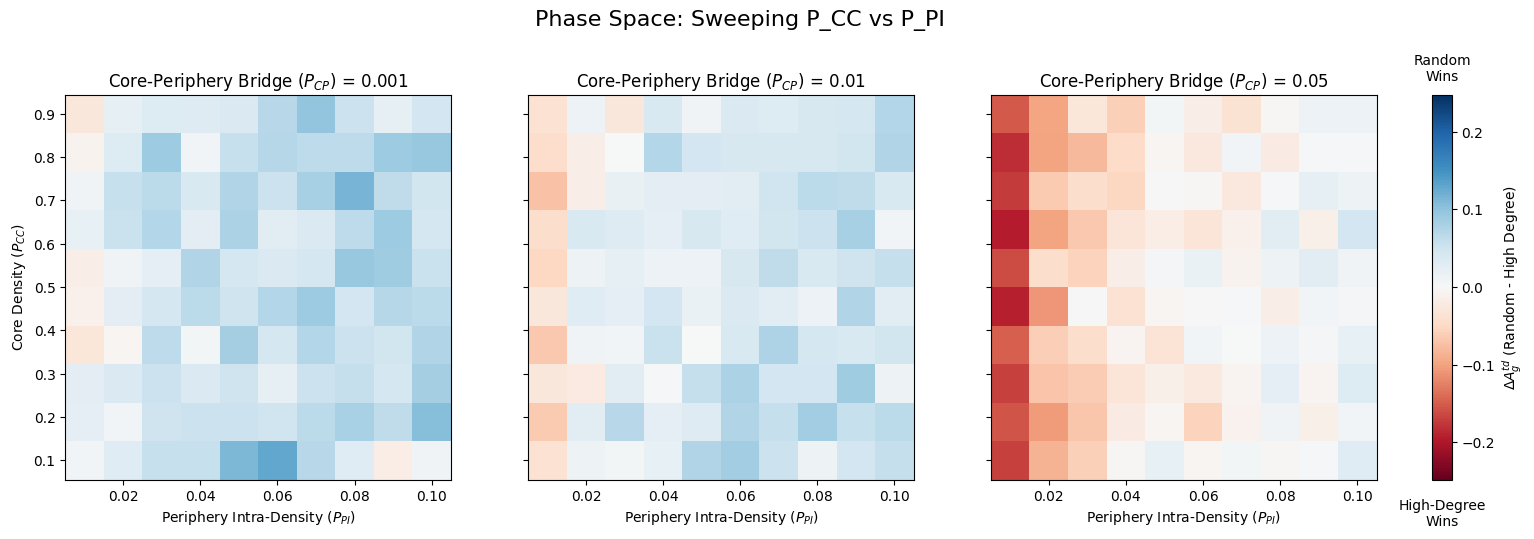

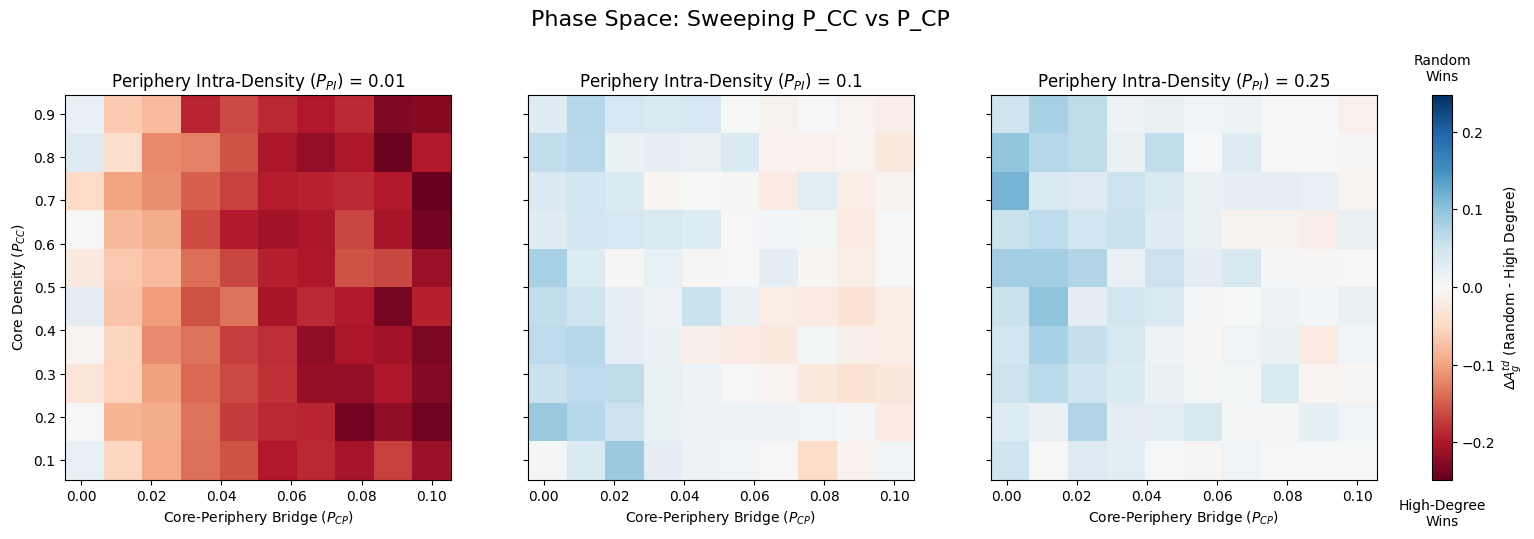

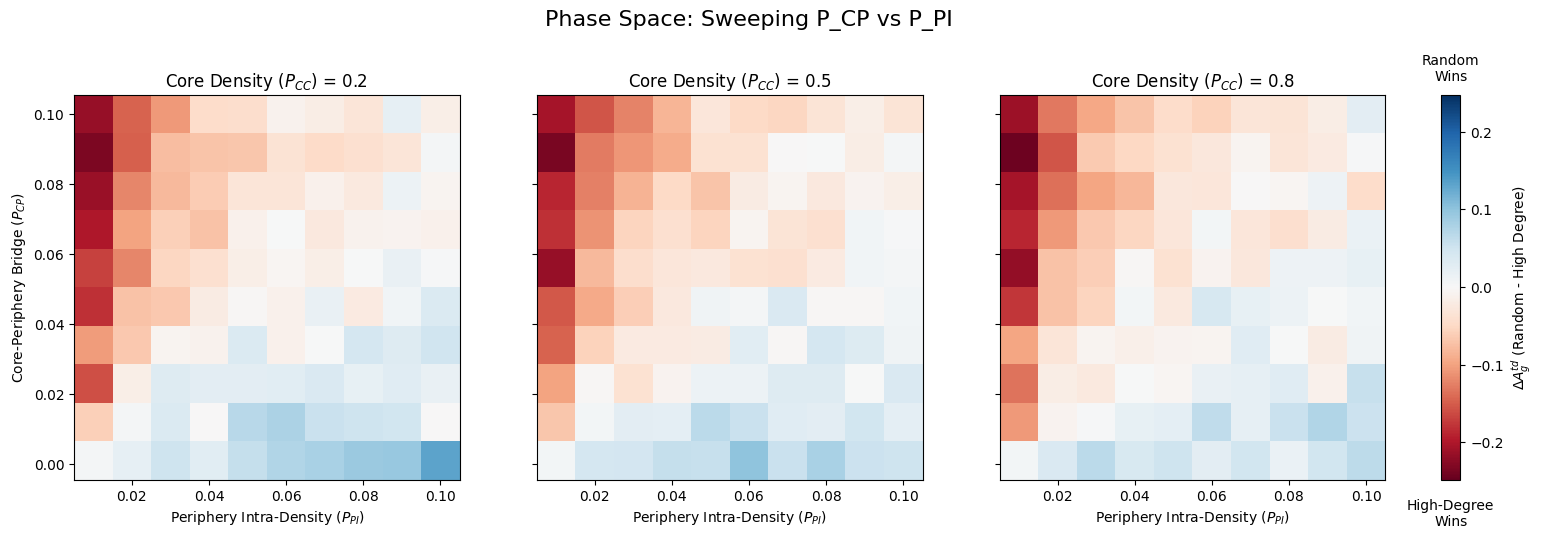

In [ ]:
# Find global max absolute value across all experiments to standardize color scales
global_max_abs = max([np.max(np.abs(tensor)) for tensor in all_results.values()])
if global_max_abs == 0:
    global_max_abs = 0.1 

for fixed_var, y_var, x_var in EXPERIMENTS:
    tensor = all_results[f"fixed_{fixed_var}"]
    fixed_vals = DISCRETE[fixed_var]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    X_mesh, Y_mesh = np.meshgrid(SWEEPS[x_var], SWEEPS[y_var])
    
    for i, ax in enumerate(axes):
        val = fixed_vals[i]
        Z = tensor[i]
        
        mesh = ax.pcolormesh(X_mesh, Y_mesh, Z, cmap='RdBu', 
                             vmin=-global_max_abs, vmax=global_max_abs, shading='nearest')
        
        ax.set_title(f"{LABELS[fixed_var]} = {val}")
        ax.set_xlabel(LABELS[x_var])
        
        if i == 0:
            ax.set_ylabel(LABELS[y_var])

    cbar = fig.colorbar(mesh, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
    cbar.set_label(r"$\Delta A_g^{td}$ (Random - High Degree)")
    cbar.ax.set_title("Random\nWins", fontsize=10, pad=10)
    cbar.ax.text(0.5, -0.05, "High-Degree\nWins", transform=cbar.ax.transAxes, 
                 ha='center', va='top', fontsize=10)

    fig.suptitle(f"Phase Space: Sweeping {y_var} vs {x_var}", fontsize=16, y=1.05)
    fig.savefig(f"../figures/cic3_sweep_fixed_{fixed_var}.png", dpi=200, bbox_inches="tight")
    plt.show()